# প্রকল্প ০৪: হোটেল সেন্টিমেন্ট অ্যানালাইসিস
## 🏨 টিএফ-আইডিএফ + লজিস্টিক রিগ্রেশন

### 🎪 গল্প দিয়ে শুরু করি

**মনে করো,** তুমি একটি নতুন হোটেলে বুকিং দিতে চাও। তুমি ইন্টারনেটে রিভিউ পড়ছো:
- "হোটেলটা অসাধারণ! স্টাফ খুব ভালো" → 😊 **পজিটিভ**
- "রুম ঠিক ছিল না, পরিষ্কার নয়" → 😞 **নেগেটিভ**

হাজার হাজার রিভিউ পড়া সম্ভব নয়! **কম্পিউটার যদি নিজেই বুঝতে পারে** — কোন রিভিউ পজিটিভ আর কোনটা নেগেটিভ?

**এটাই সেন্টিমেন্ট অ্যানালাইসিস!** আমরা মেশিনকে শেখাবো — কিছু শব্দ দেখলে বুঝবে রিভিউ ভালো নাকি খারাপ। যেমন:
- **ভালো শব্দ:** চমৎকার, অসাধারণ, পরিষ্কার, বন্ধুত্বপূর্ণ
- **খারাপ শব্দ:** ভয়ংকর, নোংরা, মিথ্যা, প্রতারণা

In [1]:
# লাইব্রেরি ইম্পোর্ট
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer  # টিএফ-আইডিএফ
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import re  # রেগুলার এক্সপ্রেশন

# ডেটা লোড
df = pd.read_csv('hotel_reviews.csv')
print('ডেটার প্রথম ৫ সারি:')
display(df.head())
print(f'\nমোট রিভিউ: {len(df)}')


ডেটার প্রথম ৫ সারি:


,review,rating
0,"It was fine, not great but not terrible either.",3
1,Amazing hotel with fantastic location and wond...,5
2,"Room was nothing like the photos, very mislead...",1
3,"Bad location, far from everything, difficult t...",1
4,"Excellent experience, the breakfast was delici...",5



মোট রিভিউ: 650


=== রেটিং অনুযায়ী রিভিউ সংখ্যা ===
rating
1    300
3     50
5    300
Name: count, dtype: int64


C:\Users\hp\AppData\Local\Temp\ipykernel_12068\597580932.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='rating', data=df, palette='RdYlGn')
C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 2480 (\N{BENGALI LETTER RA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Matplotlib currently does not support Bengali natively.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 2495 (\N{BENGALI VOWEL SIGN I}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\hp\AppData\Local\Progr

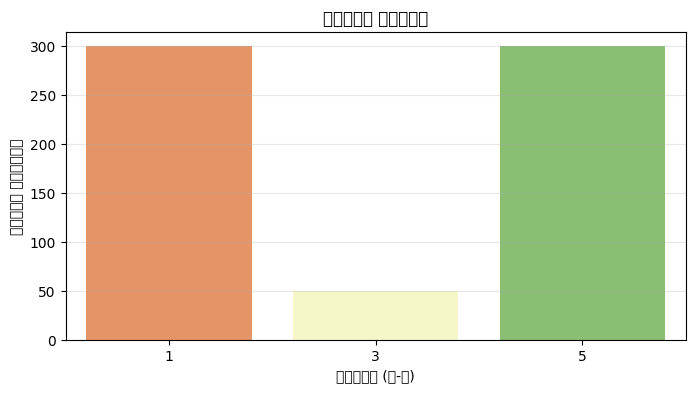

In [2]:
# রেটিং এর বিতরণ দেখা যাক
print('=== রেটিং অনুযায়ী রিভিউ সংখ্যা ===')
print(df['rating'].value_counts().sort_index())

plt.figure(figsize=(8, 4))
sns.countplot(x='rating', data=df, palette='RdYlGn')
plt.title('রেটিং বিতরণ')
plt.xlabel('রেটিং (১-৫)')
plt.ylabel('রিভিউ সংখ্যা')
plt.grid(True, alpha=0.3, axis='y')
plt.show()

## 🔧 ডেটা প্রস্তুতি
আমরা রেটিংকে সেন্টিমেন্টে রূপান্তর করবো:
- ৪ বা ৫ ⭐ → **পজিটিভ** (ভালো)
- ১ বা ২ ⭐ → **নেগেটিভ** (খারাপ)
- ৩ ⭐ → আমরা সরিয়ে দেবো (নিরপেক্ষ)

In [3]:
# সেন্টিমেন্ট তৈরি
def rating_to_sentiment(rating):
    # রেটিংকে সেন্টিমেন্টে রূপান্তর
    if rating >= 4:
        return 'পজিটিভ'  # ভালো
    elif rating <= 2:
        return 'নেগেটিভ'  # খারাপ
    else:
        return None  # নিরপেক্ষ (বাদ)

df['sentiment'] = df['rating'].apply(rating_to_sentiment)
df_clean = df.dropna(subset=['sentiment']).copy()  # নিরপেক্ষ বাদ

print(f'মোট রিভিউ: {len(df)}')
print(f'পজিটিভ + নেগেটিভ: {len(df_clean)}')
print(f'বাদ পড়া (নিরপেক্ষ): {len(df) - len(df_clean)}')
print(f'\n{df_clean["sentiment"].value_counts()}')

মোট রিভিউ: 650
পজিটিভ + নেগেটিভ: 600
বাদ পড়া (নিরপেক্ষ): 50

sentiment
পজিটিভ     300
নেগেটিভ    300
Name: count, dtype: int64


In [4]:
# টেক্সট ক্লিনিং ফাংশন
def clean_text(text):
    # টেক্সট পরিষ্কার করা
    text = text.lower()  # ছোট হাতের অক্ষরে রূপান্তর
    text = re.sub(r'[^a-zA-Z\s]', '', text)  # শুধু ইংরেজি অক্ষর রাখা
    text = re.sub(r'\s+', ' ', text).strip()  # অতিরিক্ত স্পেস সরানো
    return text

# টেক্সট ক্লিন করা
df_clean['clean_review'] = df_clean['review'].apply(clean_text)

print('=== ক্লিন করার আগে-পরে ===')
for i in range(3):
    print(f'\nআগে: {df_clean["review"].iloc[i][:80]}...')
    print(f'পরে: {df_clean["clean_review"].iloc[i][:80]}...')

=== ক্লিন করার আগে-পরে ===

আগে: Amazing hotel with fantastic location and wonderful staff!...
পরে: amazing hotel with fantastic location and wonderful staff...

আগে: Room was nothing like the photos, very misleading....
পরে: room was nothing like the photos very misleading...

আগে: Bad location, far from everything, difficult to reach....
পরে: bad location far from everything difficult to reach...


## 🔤 টিএফ-আইডিএফ ভেক্টরাইজেশন

টিএফ-আইডিএফ (TF-IDF) টেক্সটকে সংখ্যায় রূপান্তর করে। শুধু "কতবার" দেখা দিয়েছে তা নয়, বরং "কতটা গুরুত্বপূর্ণ" সেটাও বের করে!

**TF (Term Frequency):** কোনো শব্দ কতবার এসেছে
**IDF (Inverse Document Frequency):** শব্দটি কত ডকুমেন্টে এসেছে (বিরল শব্দ বেশি গুরুত্ব পায়)

In [5]:
# ফিচার (X) এবং টার্গেট (y) নির্ধারণ
X = df_clean['clean_review']  # ক্লিন করা রিভিউ
y = df_clean['sentiment']  # সেন্টিমেন্ট (পজিটিভ/নেগেটিভ)

# টিএফ-আইডিএফ ভেক্টরাইজার
tfidf = TfidfVectorizer(max_features=1000, stop_words='english')  # সর্বোচ্চ ১০০০ ফিচার
X_vec = tfidf.fit_transform(X)

print(f'ভোকাবুলারি সাইজ: {len(tfidf.get_feature_names_out())}')
print(f'ম্যাট্রিক্স শেপ: {X_vec.shape}')

# ডেটা ভাগ
X_train, X_test, y_train, y_test = train_test_split(X_vec, y, test_size=0.2, random_state=42, stratify=y)
print(f'\nট্রেন: {X_train.shape[0]}টি, টেস্ট: {X_test.shape[0]}টি')

ভোকাবুলারি সাইজ: 66
ম্যাট্রিক্স শেপ: (600, 66)

ট্রেন: 480টি, টেস্ট: 120টি


In [6]:
# সবচেয়ে গুরুত্বপূর্ণ শব্দগুলো দেখা যাক
feature_names = tfidf.get_feature_names_out()

# পজিটিভ এবং নেগেটিভ রিভিউ আলাদা করা
pos_idx = y_train == 'পজিটिव' if 'পজিটিভ' in y_train.values else y_train == 'পজিটিভ'
# Use string matching
pos_indices = np.where(y_train == 'পজিটিভ')[0]
neg_indices = np.where(y_train == 'নেগেটিভ')[0]

pos_mean = X_train[pos_indices].mean(axis=0).A1  # পজিটিভ রিভিউতে শব্দের গড়
neg_mean = X_train[neg_indices].mean(axis=0).A1  # নেগেটিভ রিভিউতে শব্দের গড়

# সবচেয়ে পজিটিভ এবং নেগেটিভ শব্দ
top_pos = np.argsort(pos_mean)[-10:][::-1]
top_neg = np.argsort(neg_mean)[-10:][::-1]

print('🔝 পজিটিভ রিভিউতে সবচেয়ে বেশি ব্যবহৃত শব্দ:')
for i in top_pos:
    print(f'   {feature_names[i]}: {pos_mean[i]:.4f}')

print('\n🔝 নেগেটিভ রিভিউতে সবচেয়ে বেশি ব্যবহৃত শব্দ:')
for i in top_neg:
    print(f'   {feature_names[i]}: {neg_mean[i]:.4f}')

🔝 পজিটিভ রিভিউতে সবচেয়ে বেশি ব্যবহৃত শব্দ:
   great: 0.1068
   service: 0.0992
   comfortable: 0.0908
   clean: 0.0908
   perfect: 0.0853
   wonderful: 0.0843
   rooms: 0.0796
   location: 0.0730
   staff: 0.0718
   hotel: 0.0681

🔝 নেগেটিভ রিভিউতে সবচেয়ে বেশি ব্যবহৃত শব্দ:
   rude: 0.0936
   terrible: 0.0913
   bad: 0.0835
   dirty: 0.0795
   staff: 0.0741
   room: 0.0716
   experience: 0.0698
   worst: 0.0655
   recommend: 0.0655
   service: 0.0614


## 🤖 লজিস্টিক রিগ্রেশন মডেল

In [7]:
# মডেল তৈরি ও শেখানো
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, y_train)

# পূর্বাভাস
y_pred = model.predict(X_test)

# নির্ভুলতা
accuracy = accuracy_score(y_test, y_pred)
print(f'🎯 মডেল নির্ভুলতা: {accuracy:.4f} ({accuracy*100:.2f}%)')

print('\n=== ক্লাসিফিকেশন রিপোর্ট ===')
print(classification_report(y_test, y_pred))

🎯 মডেল নির্ভুলতা: 1.0000 (100.00%)

=== ক্লাসিফিকেশন রিপোর্ট ===
              precision    recall  f1-score   support

     নেগেটিভ       1.00      1.00      1.00        60
      পজিটিভ       1.00      1.00      1.00        60

    accuracy                           1.00       120
   macro avg       1.00      1.00      1.00       120
weighted avg       1.00      1.00      1.00       120



C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 2472 (\N{BENGALI LETTER NA}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\seaborn\utils.py:61: UserWarning: Matplotlib currently does not support Bengali natively.
  fig.canvas.draw()
C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 2503 (\N{BENGALI VOWEL SIGN E}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 2455 (\N{BENGALI LETTER GA}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 2463 (\N{BENGALI LETTER TTA}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
C:\Users\hp\AppData\Local\Programs\Python\Py

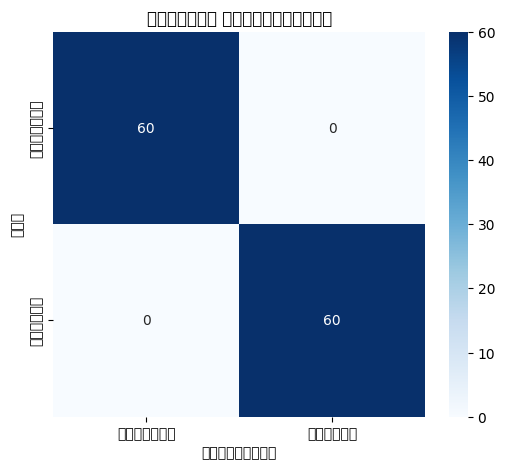


📊 কিছু উদাহরণ:
রিভিউ: Amazing hotel with fantastic location and wonderful staff!...
আসল: নেগেটিভ, পূর্বাভাস: নেগেটিভ, আত্মবিশ্বাস: 90.8%

রিভিউ: Room was nothing like the photos, very misleading....
আসল: নেগেটিভ, পূর্বাভাস: নেগেটিভ, আত্মবিশ্বাস: 92.5%

রিভিউ: Bad location, far from everything, difficult to reach....
আসল: পজিটিভ, পূর্বাভাস: পজিটিভ, আত্মবিশ্বাস: 90.2%

রিভিউ: Excellent experience, the breakfast was delicious....
আসল: পজিটিভ, পূর্বাভাস: পজিটিভ, আত্মবিশ্বাস: 94.6%

রিভিউ: Bad location, far from everything, difficult to reach....
আসল: পজিটিভ, পূর্বাভাস: পজিটিভ, আত্মবিশ্বাস: 88.4%



In [8]:
# কনফিউশন ম্যাট্রিক্স
plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['নেগেটিভ', 'পজিটিভ'],
            yticklabels=['নেগেটিভ', 'পজিটিভ'])
plt.title('কনফিউশন ম্যাট্রিক্স')
plt.xlabel('পূর্বাভাস')
plt.ylabel('আসল')
plt.show()

# মডেলের আত্মবিশ্বাস
probs = model.predict_proba(X_test)
print(f'\n📊 কিছু উদাহরণ:')
for i in range(5):
    pred = y_pred[i]
    prob = max(probs[i]) * 100
    print(f'রিভিউ: {df_clean["review"].iloc[i][:60]}...')
    print(f'আসল: {y_test.iloc[i]}, পূর্বাভাস: {pred}, আত্মবিশ্বাস: {prob:.1f}%\n')

## 🧪 নিজের রিভিউ টেস্ট করো!
তুমি নিজে একটি রিভিউ লিখে দেখতে পারো — মডেল কি বলে?

In [9]:
# নিজের রিভিউ টেস্ট
my_reviews = [
    'The hotel was amazing, very clean and wonderful staff!',
    'This place is terrible, dirty rooms and rude staff.',
    'It was okay, nothing special but not terrible either.',
    'I loved the location and the breakfast was delicious!'
]

for review in my_reviews:
    cleaned = clean_text(review)
    vec = tfidf.transform([cleaned])
    pred = model.predict(vec)[0]
    prob = max(model.predict_proba(vec)[0]) * 100
    emoji = '😊' if pred == 'পজিটিভ' else '😞'
    print(f'{emoji} "{review}"')
    print(f'   → {pred} (আত্মবিশ্বাস: {prob:.1f}%)\n')

😊 "The hotel was amazing, very clean and wonderful staff!"
   → পজিটিভ (আত্মবিশ্বাস: 91.3%)

😞 "This place is terrible, dirty rooms and rude staff."
   → নেগেটিভ (আত্মবিশ্বাস: 88.0%)

😞 "It was okay, nothing special but not terrible either."
   → নেগেটিভ (আত্মবিশ্বাস: 87.7%)

😊 "I loved the location and the breakfast was delicious!"
   → পজিটিভ (আত্মবিশ্বাস: 91.2%)



## 🎯 তুমি কি শিখলে?

| ধারণা | বাংলায় অর্থ |
|-------|-------------|
| **সেন্টিমেন্ট অ্যানালাইসিস** | টেক্সট পড়ে অনুভূতি বোঝা (ভালো/খারাপ) |
| **টিএফ-আইডিএফ (TF-IDF)** | শব্দের গুরুত্ব অনুযায়ী সংখ্যায় রূপান্তর |
| **টেক্সট ক্লিনিং** | অপ্রয়োজনীয় অংশ বাদ দিয়ে টেক্সট পরিষ্কার করা |
| **লজিস্টিক রিগ্রেশন** | সম্ভাবনা বের করে ক্লাসিফিকেশন |
| **কনফিউশন ম্যাট্রিক্স** | মডেলের সঠিক ও ভুল পূর্বাভাস দেখার ছক |

**মনে রাখবে:** কম্পিউটার ভাষা বোঝে না! আমরা টেক্সটকে সংখ্যায় রূপান্তর করে দেই, তারপর মেশিন লার্নিং ব্যবহার করে সেন্টিমেন্ট অনুমান করি। ব্যবসায়ীরা এই পদ্ধতি ব্যবহার করে গ্রাহকের মতামত বুঝতে পারে! 🏨